# 9. 金融新闻文本分析与股价联动

## 一、实验简介

本实验基于 **FNSPID**（Financial News and Stock Price Integration Dataset, Dong et al., KDD 2024）开展金融新闻情感分析与股价联动研究。FNSPID 包含约 2970 万条股价记录和约 1570 万条新闻记录，覆盖 4,775 家 S&P500 公司（1999–2023）。

> 数据来源：<https://huggingface.co/datasets/Zihan1004/FNSPID>
> 论文：
> ```
> @misc{dong2024fnspid,
>  title={FNSPID: A Comprehensive Financial News Dataset in Time Series},
>  author={Zihan Dong and Xinyu Fan and Zhiyuan Peng},
>  year={2024},
>  eprint={2402.06698},
>  archivePrefix={arXiv},
>  primaryClass={q-fin.ST}
>}
> ```

由于完整新闻数据超过 23 GB，本实验聚焦于 **单只股票（AAPL）** 的子集进行演示。

本实验对比两种情感分析方法：
1. **朴素贝叶斯（Naive Bayes）**：在带标签的 Financial PhraseBank 上训练，然后迁移应用到 FNSPID 新闻。
2. **FinBERT（仅推理，不微调）**：利用预训练金融领域 BERT 模型直接进行情感推理，充分利用 CUDA 加速。

最终将两种方法产出的情绪指标与股价收益率进行事件窗口联动分析。

## 二、实验目标

- 掌握大规模金融文本的清洗与预处理流程。
- 理解朴素贝叶斯在文本分类任务中的原理与局限。
- 掌握 FinBERT 预训练模型的推理式使用（无需微调），体会迁移学习的优势。
- 构建日度情绪指标，完成事件窗口分析，探索情绪与股价的联动关系。

## 三、实验要求

- 对比朴素贝叶斯与 FinBERT 在相同测试集上的分类效果。
- 利用 FinBERT 对 FNSPID 新闻进行情绪打分，构建日度情绪指标。
- 完成事件窗口分析（新闻发布前后股价异常收益率），形成联动结论。

## 四、思考提示

1. 朴素贝叶斯依赖人工标注数据训练，FinBERT 直接推理——各有什么优缺点？
2. 当新闻文本较长时，朴素贝叶斯的词袋假设会面临哪些挑战？
3. 情绪指标与股价的关系是因果关系还是相关关系？如何区分？

---

## 1. 环境配置

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# ---------- CUDA 检查 ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch 设备: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

import matplotlib.font_manager as fm

!wget -O SourceHanSerifCN-Regular.ttf https://raw.githubusercontent.com/wordshub/free-font/refs/heads/master/assets/font/%E4%B8%AD%E6%96%87/%E6%80%9D%E6%BA%90%E5%AD%97%E4%BD%93%E7%B3%BB%E5%88%97/%E6%80%9D%E6%BA%90%E5%AE%8B%E4%BD%93/SourceHanSerifCN-Regular.ttf
font_path = "SourceHanSerifCN-Regular.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.family'] = font_name

RANDOM_STATE = 196823
TEST_SIZE = 0.2
TARGET_TICKER = "AAPL"  # 本实验聚焦的股票

PyTorch 设备: cuda
  GPU: Tesla T4
--2026-10-05 02:28:14--  https://raw.githubusercontent.com/wordshub/free-font/refs/heads/master/assets/font/%E4%B8%AD%E6%96%87/%E6%80%9D%E6%BA%90%E5%AD%97%E4%BD%93%E7%B3%BB%E5%88%97/%E6%80%9D%E6%BA%90%E5%AE%8B%E4%BD%93/SourceHanSerifCN-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14495132 (14M) [application/octet-stream]
Saving to: ‘SourceHanSerifCN-Regular.ttf’

SourceHanSerifCN-Re 100%[===================>]  13.82M  --.-KB/s    in 0.08s   

2026-10-05 02:28:14 (167 MB/s) - ‘SourceHanSerifCN-Regular.ttf’ saved [14495132/14495132]



---

## 2. 数据获取

### 2.1 带标签数据：Financial PhraseBank

用于训练朴素贝叶斯，同时作为 NB 与 FinBERT 的公平对比测试集。

In [2]:
import zipfile
from huggingface_hub import hf_hub_download

def load_financial_phrasebank() -> tuple[pd.Series, pd.Series]:
    """加载 Financial PhraseBank（sentences_allagree 子集）。

    Ref: https://huggingface.co/datasets/financial_phrasebank
    """
    zip_path = hf_hub_download(
        repo_id="financial_phrasebank",
        repo_type="dataset",
        filename="data/FinancialPhraseBank-v1.0.zip",
    )
    with zipfile.ZipFile(zip_path) as zf:
        raw = zf.read(
            "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"
        ).decode("latin-1").splitlines()

    records = []
    for line in raw:
        sentence, label = line.rsplit("@", 1)
        records.append({"sentence": sentence.strip(), "label": label.strip()})
    df = pd.DataFrame(records)
    return df["sentence"], df["label"]

X_fpb, y_fpb = load_financial_phrasebank()
print(f"Financial PhraseBank 样本数: {len(X_fpb)}")
print(y_fpb.value_counts())

data/FinancialPhraseBank-v1.0.zip: reconstructing file:   0%|          |  0.00B /  682kB            

data/FinancialPhraseBank-v1.0.zip: downloading bytes:           |  0.00B            

Financial PhraseBank 样本数: 2264
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fpb, y_fpb,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_fpb,
)
print(f"训练集: {len(X_train)}  测试集: {len(X_test)}")

训练集: 1811  测试集: 453


### 2.2 FNSPID 新闻与股价数据

FNSPID 完整新闻数据超过 23 GB（单一 CSV），无法按股票单独下载。本实验使用社区维护的 Nasdaq-100 子集 `benstaf/FNSPID-filtered-nasdaq-100`（约 825 MB，358k 行），该数据集已在 HuggingFace 上自动转换为 Parquet 格式。

通过 HuggingFace `datasets` 库的**流式加载**（streaming）功能，可以在不下载完整文件的前提下，逐块扫描并仅保留目标股票的记录。

> 新闻数据来源：<https://huggingface.co/datasets/benstaf/FNSPID-filtered-nasdaq-100>
> 原始 FNSPID 仓库：<https://github.com/Zdong104/FNSPID_Financial_News_Dataset>

In [4]:
from datasets import load_dataset

FNSPID_NEWS_CACHE = Path(f"data/fnspid_news_{TARGET_TICKER.lower()}.parquet")

def load_fnspid_news_streaming(
    ticker: str = TARGET_TICKER,
    cache_path: Path = FNSPID_NEWS_CACHE,
    max_rows: int | None = None,
) -> pd.DataFrame:
    """通过 HuggingFace streaming 加载单只股票的 FNSPID 新闻子集。

    首次运行会流式扫描远程 Parquet 文件，仅下载匹配行，
    并缓存到本地 parquet 文件，后续运行直接读取缓存。

    Ref: https://huggingface.co/docs/datasets/en/stream
    Ref: https://huggingface.co/datasets/benstaf/FNSPID-filtered-nasdaq-100
    """
    # 1) 如果本地缓存存在，直接读取
    if cache_path.exists():
        print(f"从本地缓存加载: {cache_path}")
        df = pd.read_parquet(cache_path)
        if max_rows is not None:
            df = df.head(max_rows)
        return df

    # 2) 流式加载，按 ticker 过滤
    print(f"正在从 HuggingFace 流式加载 {ticker} 的新闻数据...")
    print("  数据集: benstaf/FNSPID-filtered-nasdaq-100")
    print("  首次运行需扫描远程数据，可能需要几分钟，请耐心等待...")

    ds = load_dataset(
        "benstaf/FNSPID-filtered-nasdaq-100",
        split="train",
        streaming=True,
    )
    # Ref: https://huggingface.co/docs/datasets/en/process#filter
    ticker_upper = ticker.upper()
    filtered = ds.filter(
        lambda x: str(x.get("Stock_symbol", "")).upper() == ticker_upper
    )

    # 收集所有匹配行
    rows = []
    for i, row in enumerate(filtered):
        rows.append(row)
        if (i + 1) % 1000 == 0:
            print(f"  已收集 {i + 1} 条...", end="\r")

    if not rows:
        raise ValueError(
            f"未找到 ticker={ticker} 的新闻。"
            "请检查 Stock_symbol 列的取值（如 'AAPL'）。"
        )

    df = pd.DataFrame(rows)
    print(f"\n  共获取 {len(df)} 条 {ticker} 新闻")

    # 3) 缓存到本地
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path, index=False)
    print(f"  已缓存到: {cache_path}")

    if max_rows is not None:
        df = df.head(max_rows)
    return df

In [5]:
# --- 加载新闻 ---
try:
    news_df = load_fnspid_news_streaming(ticker=TARGET_TICKER)
    print(f"\nFNSPID {TARGET_TICKER} 新闻记录数: {len(news_df)}")
    print(f"列名: {list(news_df.columns)}")
    print(news_df.head(3))
    HAS_FNSPID_NEWS = True
except Exception as e:
    print(f"⚠️ 加载 FNSPID 新闻失败: {e}")
    print("将仅使用 Financial PhraseBank 进行 NB vs FinBERT 对比。")
    print("股价联动分析部分将使用模拟数据演示。")
    HAS_FNSPID_NEWS = False

正在从 HuggingFace 流式加载 AAPL 的新闻数据...
  数据集: benstaf/FNSPID-filtered-nasdaq-100
  首次运行需扫描远程数据，可能需要几分钟，请耐心等待...


README.md:   0%|          | 0.00/733 [00:00<?, ?B/s]


  共获取 9338 条 AAPL 新闻
  已缓存到: data/fnspid_news_aapl.parquet

FNSPID AAPL 新闻记录数: 9338
列名: ['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
  Unnamed: 0                     Date  \
0    12025.0  2023-12-16 22:00:00 UTC   
1    12026.0  2023-12-16 22:00:00 UTC   
2    12027.0  2023-12-16 21:00:00 UTC   

                                       Article_title Stock_symbol  \
0  My 6 Largest Portfolio Holdings Heading Into 2...         AAPL   
1  Brokers Suggest Investing in Apple (AAPL): Rea...         AAPL   
2                      Company News for Dec 19, 2023         AAPL   

                                                 Url Publisher Author  \
0  https://www.nasdaq.com/articles/my-6-largest-p...                    
1  https://www.nasdaq.com/articles/brokers-sugges...                    
2  https://www.nasdaq.com/articles/company-news-f...                    

         

### 2.3 股价数据

FNSPID 的股价数据同样以大文件形式分发，无法按个股单独下载。本实验直接使用 `yfinance` 获取目标股票的历史日线数据，覆盖与新闻相同的时间范围。

> Ref: https://github.com/ranaroussi/yfinance

In [27]:
"""### 2.3 股价数据

读取 FNSPID 股价数据并修补 2020-07 至 2022-07 缺失区间（或通过 yfinance 完整对齐）。

> Ref: https://github.com/ranaroussi/yfinance
> Ref: https://pandas.pydata.org/docs/reference/api/pandas.concat.html
"""

from pathlib import Path
import yfinance as yf

def load_price_data(
    ticker: str = TARGET_TICKER,
    start: str = "2010-01-01",
    end: str = "2024-01-01",
    fnspid_csv_path: str | Path | None = None,
) -> pd.DataFrame:
    """加载股价数据；若为 FNSPID 原始文件，则自动修补 2020-07 ~ 2022-07 缺失断档。

    Ref: https://github.com/ranaroussi/yfinance
    Ref: https://pandas.pydata.org/docs/reference/api/pandas.concat.html
    """
    candidate_paths = [
        Path(fnspid_csv_path) if fnspid_csv_path else None,
        Path(f"data/{ticker}.csv"),
        Path(f"{ticker}.csv"),
        Path(f"data/{ticker.lower()}.csv"),
    ]
    csv_file = next((p for p in candidate_paths if p and p.exists()), None)

    if csv_file:
        print(f"检测到 FNSPID 原始股价文件: {csv_file}，正在加载并修补 2020-07 ~ 2022-07 缺失断档...")
        df_fnspid = pd.read_csv(csv_file)

        # 统一列名格式
        col_map = {c: c.capitalize() for c in df_fnspid.columns}
        for c in df_fnspid.columns:
            if c.lower() in ["adj close", "adjclose"]:
                col_map[c] = "Adj Close"
        df_fnspid.rename(columns=col_map, inplace=True)
        df_fnspid["Date"] = pd.to_datetime(df_fnspid["Date"]).dt.tz_localize(None)

        df = df.drop_duplicates(subset=["Date"]).sort_values("Date").reset_index(drop=True)
        df = df[(df["Date"] >= start) & (df["Date"] <= end)].reset_index(drop=True)
        print(f"  修复完成，共 {len(df)} 条日线数据")
        return df

    # 未找到本地 FNSPID 文件时回退为直接拉取连续历史数据
    print(f"未检测到 FNSPID 本地文件，通过 yfinance 下载连续 {ticker} 股价数据 ({start} ~ {end})...")
    tk = yf.Ticker(ticker)
    df = tk.history(start=start, end=end, auto_adjust=False).reset_index()
    if "Date" not in df.columns and "index" in df.columns:
        df = df.rename(columns={"index": "Date"})
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
    df = df.sort_values("Date").reset_index(drop=True)
    print(f"  获取 {len(df)} 条日线数据")
    return df

price_df = load_price_data(ticker=TARGET_TICKER)
print(price_df[["Date", "Close"]].tail())

未检测到 FNSPID 本地文件，通过 yfinance 下载连续 AAPL 股价数据 (2010-01-01 ~ 2024-01-01)...
  获取 3522 条日线数据
           Date       Close
3517 2023-12-22  193.600006
3518 2023-12-26  193.050003
3519 2023-12-27  193.149994
3520 2023-12-28  193.580002
3521 2023-12-29  192.529999


### 2.4 数据概览

In [28]:
print("=" * 60)
print(f"Financial PhraseBank: {len(X_fpb)} 条带标签句子")
print(f"  训练集: {len(X_train)}  测试集: {len(X_test)}")
print(f"  类别分布:\n{y_fpb.value_counts().to_string()}")
print()
if HAS_FNSPID_NEWS:
    print(f"FNSPID 新闻 ({TARGET_TICKER}): {len(news_df)} 条")
else:
    print(f"FNSPID 新闻: 未加载")
print(f"股价数据 ({TARGET_TICKER}): {len(price_df)} 个交易日")
print("=" * 60)

Financial PhraseBank: 2264 条带标签句子
  训练集: 1811  测试集: 453
  类别分布:
label
neutral     1391
positive     570
negative     303

FNSPID 新闻 (AAPL): 9338 条
股价数据 (AAPL): 3522 个交易日


## 3. 文本清洗

In [8]:
def clean_text(text: str) -> str:
    """基础文本清洗：去 HTML 标签、多余空白、转小写。"""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)       # 去 HTML
    text = re.sub(r"http\S+", " ", text)        # 去 URL
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'-]", " ", text)  # 保留基本标点
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

# 清洗 Financial PhraseBank
X_train_clean = X_train.map(clean_text)
X_test_clean = X_test.map(clean_text)

print("清洗前:", X_test.iloc[0][:80])
print("清洗后:", X_test_clean.iloc[0][:80])

清洗前: In Finland , the city of Forssa has said it will not pay compensation to food in
清洗后: in finland , the city of forssa has said it will not pay compensation to food in


---

## 4. 朴素贝叶斯模型

与第 4 章相同的方法论，此处选取表现最优的 **TF-IDF + α=0.1** 方案。

In [9]:
def build_nb_pipeline(
    vectorizer_type: str = "tfidf",
    alpha: float = 0.1,
    max_features: int = 10000,
) -> Pipeline:
    if vectorizer_type == "tfidf":
        vec = TfidfVectorizer(max_features=max_features, stop_words="english")
    else:
        vec = CountVectorizer(max_features=max_features, stop_words="english")
    return Pipeline([
        ("vectorizer", vec),
        ("nb", MultinomialNB(alpha=alpha)),
    ])

nb_model = build_nb_pipeline("tfidf", alpha=0.1)
t0 = perf_counter()
nb_model.fit(X_train_clean, y_train)
nb_fit_time = perf_counter() - t0
print(f"朴素贝叶斯训练耗时: {nb_fit_time:.4f}s")

nb_preds = nb_model.predict(X_test_clean)
print("\n=== 朴素贝叶斯 分类报告 ===")
print(classification_report(y_test, nb_preds, digits=4))

朴素贝叶斯训练耗时: 0.0639s

=== 朴素贝叶斯 分类报告 ===
              precision    recall  f1-score   support

    negative     0.8065    0.4098    0.5435        61
     neutral     0.8935    0.9353    0.9139       278
    positive     0.6718    0.7719    0.7184       114

    accuracy                         0.8234       453
   macro avg     0.7906    0.7057    0.7252       453
weighted avg     0.8260    0.8234    0.8148       453



---

## 5. FinBERT 推理（CUDA 加速）

FinBERT 是在金融文本上预训练的 BERT 模型，可直接用于情感分类（positive / negative / neutral），无需微调。

> 模型来源：<https://huggingface.co/ProsusAI/finbert>

**注意**：此处仅做推理（inference），不进行任何梯度计算或参数更新，是迁移学习中最轻量的使用方式。

In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

FINBERT_MODEL_NAME = "ProsusAI/finbert"
# Ref: https://huggingface.co/ProsusAI/finbert

print(f"加载 FinBERT 模型到 {DEVICE}...")
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL_NAME)
finbert_model = AutoModelForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME
).to(DEVICE)
finbert_model.eval()  # 推理模式，关闭 dropout 等

FINBERT_LABELS = ["positive", "negative", "neutral"]

加载 FinBERT 模型到 cuda...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

In [11]:
def finbert_predict_batch(
    texts: list[str],
    tokenizer=finbert_tokenizer,
    model=finbert_model,
    device=DEVICE,
    batch_size: int = 64,
) -> tuple[list[str], list[dict]]:
    """批量 FinBERT 推理，返回 (预测标签列表, 各类概率字典列表)。

    利用 CUDA 进行批量推理加速。
    """
    all_labels = []
    all_scores = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        # tokenize，截断到 512 tokens（BERT 上限）
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():  # 推理，不计算梯度
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)

        for j in range(len(batch_texts)):
            prob_dict = {
                FINBERT_LABELS[k]: float(probs[j, k])
                for k in range(len(FINBERT_LABELS))
            }
            pred_idx = int(probs[j].argmax())
            all_labels.append(FINBERT_LABELS[pred_idx])
            all_scores.append(prob_dict)

    return all_labels, all_scores

In [12]:
# 在测试集上运行 FinBERT 推理
test_texts = X_test_clean.tolist()

t0 = perf_counter()
finbert_preds, finbert_scores = finbert_predict_batch(test_texts)
finbert_time = perf_counter() - t0
print(f"FinBERT 推理耗时: {finbert_time:.2f}s ({len(test_texts)} 条)")
print(f"  每条平均: {finbert_time / len(test_texts) * 1000:.1f}ms")

FinBERT 推理耗时: 3.95s (453 条)
  每条平均: 8.7ms


---

## 6. 朴素贝叶斯 vs FinBERT 对比

### 6.1 分类报告对比

In [13]:
print("=== FinBERT 分类报告 ===")
print(classification_report(y_test, finbert_preds, digits=4))

print("\n=== 朴素贝叶斯 分类报告 ===")
print(classification_report(y_test, nb_preds, digits=4))

=== FinBERT 分类报告 ===
              precision    recall  f1-score   support

    negative     0.8592    1.0000    0.9242        61
     neutral     0.9963    0.9748    0.9855       278
    positive     0.9727    0.9386    0.9554       114

    accuracy                         0.9691       453
   macro avg     0.9427    0.9711    0.9550       453
weighted avg     0.9719    0.9691    0.9696       453


=== 朴素贝叶斯 分类报告 ===
              precision    recall  f1-score   support

    negative     0.8065    0.4098    0.5435        61
     neutral     0.8935    0.9353    0.9139       278
    positive     0.6718    0.7719    0.7184       114

    accuracy                         0.8234       453
   macro avg     0.7906    0.7057    0.7252       453
weighted avg     0.8260    0.8234    0.8148       453



### 6.2 指标对比表

In [14]:
label_names = ["negative", "neutral", "positive"]

def calc_metrics(y_true, y_pred, name: str) -> dict:
    return {
        "模型": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1-macro": f1_score(y_true, y_pred, average="macro"),
    }

compare_df = pd.DataFrame([
    calc_metrics(y_test, nb_preds, "朴素贝叶斯 (TF-IDF)"),
    calc_metrics(y_test, finbert_preds, "FinBERT (推理)"),
])
compare_df = compare_df.set_index("模型")
print(compare_df)

                Accuracy  F1-macro
模型                                
朴素贝叶斯 (TF-IDF)  0.823400  0.725243
FinBERT (推理)    0.969095  0.955018


### 6.3 混淆矩阵对比

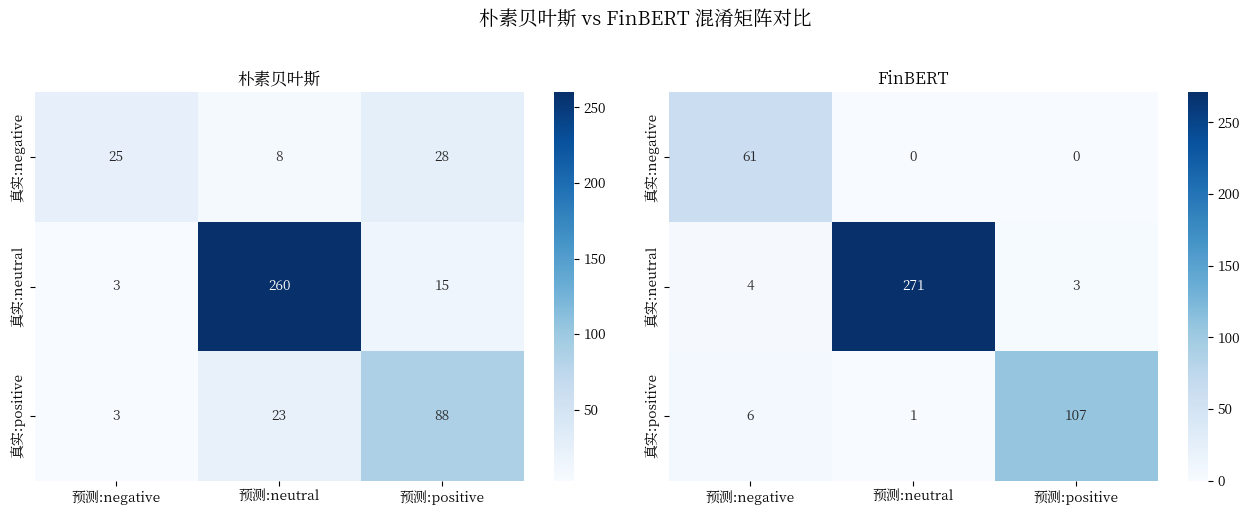

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (preds, title) in zip(axes, [
    (nb_preds, "朴素贝叶斯"),
    (finbert_preds, "FinBERT"),
]):
    cm = confusion_matrix(y_test, preds, labels=label_names)
    cm_df = pd.DataFrame(
        cm,
        index=[f"真实:{lb}" for lb in label_names],
        columns=[f"预测:{lb}" for lb in label_names],
    )
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)

fig.suptitle("朴素贝叶斯 vs FinBERT 混淆矩阵对比", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 6.4 速度 vs 精度权衡

In [16]:
print(f"朴素贝叶斯训练+预测总耗时: {nb_fit_time:.4f}s")
print(f"FinBERT 推理耗时 (CUDA):    {finbert_time:.2f}s")
print(f"\nFinBERT 速度约为 NB 的 {finbert_time / nb_fit_time:.0f} 倍")
print("但 FinBERT 无需标注数据，直接迁移使用。")

朴素贝叶斯训练+预测总耗时: 0.0639s
FinBERT 推理耗时 (CUDA):    3.95s

FinBERT 速度约为 NB 的 62 倍
但 FinBERT 无需标注数据，直接迁移使用。


---

## 7. 情绪指标构建与股价联动分析

本节使用 FinBERT 对新闻进行情绪打分，并与股价收益率进行联动分析。

### 7.1 构建日度情绪指标

In [39]:
def compute_sentiment_score(prob_dict: dict) -> float:
    """将 FinBERT 三分类概率转为连续情绪分数 ∈ [-1, 1]。

    score = P(positive) - P(negative)
    """
    return prob_dict["positive"] - prob_dict["negative"]

# 使用 FNSPID 新闻子集
# FNSPID 列名: Article_title / Article / Date
if "Article_title" in news_df.columns:
    text_col = "Article_title"
elif "Article" in news_df.columns:
    text_col = "Article"
else:
    raise KeyError("FNSPID 新闻缺少文本列：Article_title 或 Article")

if "Date" in news_df.columns:
    date_col = "Date"
else:
    raise KeyError("FNSPID 新闻缺少日期列：Date")

# Ref: https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
# 1. 过滤：仅提取断层后 (>= 2022-07-01) 的新闻数据，避免对废弃的前置数据进行无谓的 GPU 推理
POST_GAP_START = pd.to_datetime("2022-07-01")

filtered_news_df = news_df.copy()
filtered_news_df["parsed_date"] = pd.to_datetime(
    filtered_news_df[date_col], errors="coerce"
).dt.tz_localize(None)

filtered_news_df = filtered_news_df[
    filtered_news_df["parsed_date"] >= POST_GAP_START
].dropna(subset=["parsed_date", text_col]).reset_index(drop=True)

filtered_news_df["date"] = filtered_news_df["parsed_date"].dt.floor("D")

print(f"原始新闻总数: {len(news_df)} 条")
print(f"过滤后（>= 2022-07-01）待推理新闻数: {len(filtered_news_df)} 条")

# 2. 仅对过滤后的新闻文本进行清洗与 FinBERT 批量推理
# Ref: https://huggingface.co/docs/transformers/main_classes/pipelines
news_texts = filtered_news_df[text_col].map(clean_text).tolist()

print(f"开始对 {len(news_texts)} 条后断层新闻进行 FinBERT 情绪推理...")
t0 = perf_counter()
_, news_scores = finbert_predict_batch(news_texts)
print(f"  FinBERT 推理完成，耗时: {perf_counter() - t0:.1f}s")

# 3. 计算情绪分并按交易日聚合
# Ref: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
filtered_news_df["sentiment_score"] = [compute_sentiment_score(s) for s in news_scores]

daily_sentiment = (
    filtered_news_df.groupby("date")["sentiment_score"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_sentiment", "count": "news_count"})
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"断层后日度情绪指标天数: {len(daily_sentiment)}")
print(f"覆盖时间范围: {daily_sentiment['date'].min().date()} 至 {daily_sentiment['date'].max().date()}")
daily_sentiment.head()

原始新闻总数: 9338 条
过滤后（>= 2022-07-01）待推理新闻数: 8423 条
开始对 8423 条后断层新闻进行 FinBERT 情绪推理...
  FinBERT 推理完成，耗时: 26.2s
断层后日度情绪指标天数: 531
覆盖时间范围: 2022-07-01 至 2023-12-16


,date,avg_sentiment,news_count
0,2022-07-01,0.062276,18
1,2022-07-02,-0.196393,9
2,2022-07-03,0.176727,4
3,2022-07-04,0.228612,9
4,2022-07-05,-0.052339,11


### 7.2 计算股价收益率

In [40]:
price_df = price_df.copy()
price_df["Date"] = pd.to_datetime(price_df["Date"])
# 保留交易日
price_df = price_df.sort_values("Date").reset_index(drop=True)

# 日收益率
close_col = "Close" if "Close" in price_df.columns else "Adj Close"
price_df["return"] = price_df[close_col].pct_change()

print(price_df[["Date", close_col, "return"]].tail())

           Date       Close    return
3517 2023-12-22  193.600006 -0.005547
3518 2023-12-26  193.050003 -0.002841
3519 2023-12-27  193.149994  0.000518
3520 2023-12-28  193.580002  0.002226
3521 2023-12-29  192.529999 -0.005424


### 7.3 合并情绪与收益率

In [41]:
merged = pd.merge(
    daily_sentiment,
    price_df[["Date", "return"]].rename(columns={"Date": "date"}),
    on="date",
    how="inner",
)
print(f"合并后有效记录数: {len(merged)}")
merged.head()

合并后有效记录数: 368


,date,avg_sentiment,news_count,return
0,2022-07-01,0.062276,18,0.016164
1,2022-07-05,-0.052339,11,0.018930
2,2022-07-06,0.154910,16,0.009607
3,2022-07-07,0.075181,16,0.023999
4,2022-07-08,-0.313561,6,0.004715


### 7.4 相关性分析

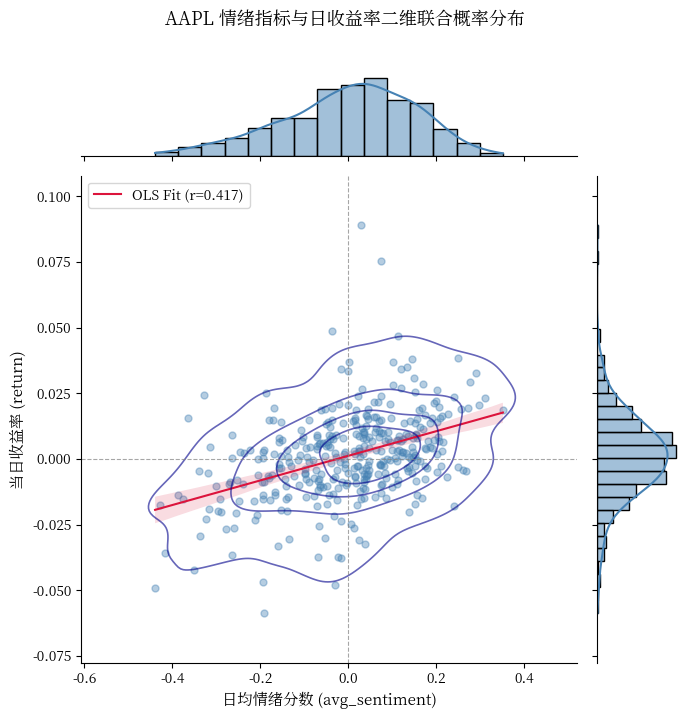

In [43]:
    # Ref: https://seaborn.pydata.org/generated/seaborn.jointplot.html
    # Ref: https://seaborn.pydata.org/generated/seaborn.kdeplot.html
    # 绘制二维联合概率密度分布图 (2D Joint Probability Distribution)
    # 滤除缺失值
    plot_data = merged.dropna(subset=["avg_sentiment", "return"])

    g = sns.jointplot(
        data=plot_data,
        x="avg_sentiment",
        y="return",
        kind="reg",  # 散点 + 线性回归拟合线
        scatter_kws={"alpha": 0.4, "color": "steelblue", "s": 25},
        line_kws={"color": "crimson", "linewidth": 1.5, "label": f"OLS Fit (r={corr:.3f})"},
        marginal_kws={"fill": True, "color": "steelblue", "kde": True},
        height=7,
    )

    # 叠加 2D KDE 等高线以显示二维联合概率密度
    sns.kdeplot(
        data=plot_data,
        x="avg_sentiment",
        y="return",
        levels=5,
        color="darkblue",
        alpha=0.6,
        linewidths=1.2,
        ax=g.ax_joint,
    )

    # 辅助参考线 (0, 0)
    g.ax_joint.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    g.ax_joint.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    g.ax_joint.set_xlabel("日均情绪分数 (avg_sentiment)", fontsize=11)
    g.ax_joint.set_ylabel("当日收益率 (return)", fontsize=11)
    g.ax_joint.legend(loc="upper left")

    g.fig.suptitle(
        f"{TARGET_TICKER} 情绪指标与日收益率二维联合概率分布",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

### 7.5 事件窗口分析

选取情绪极端日（正面/负面前 5%）作为"事件"，分析事件前后 [-2, +2] 天的累积异常收益率（CAR）。

事件类型  偏移天数   平均异常收益率  事件数
 极正面    -2  0.005069   23
 极正面    -1  0.007544   23
 极正面     0  0.019539   23
 极正面     1 -0.001681   23
 极正面     2 -0.003417   23
 极负面    -2 -0.004331   21
 极负面    -1  0.005965   22
 极负面     0 -0.020347   23
 极负面     1  0.005423   23
 极负面     2 -0.007680   23


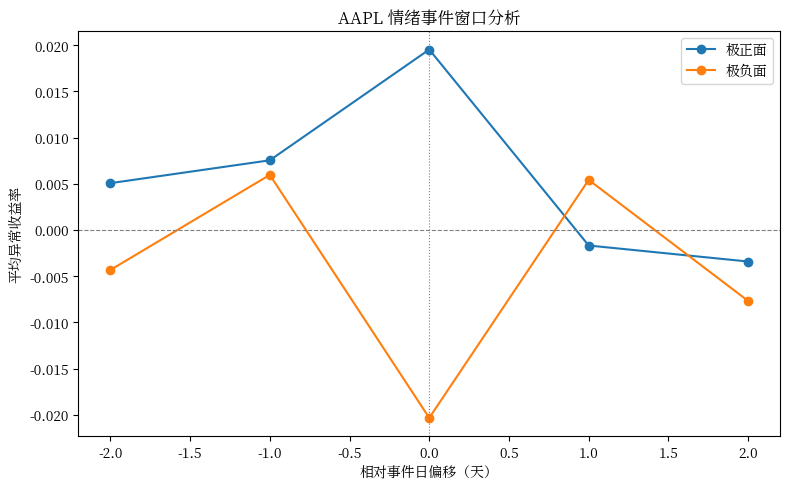

In [21]:
def event_window_analysis(
    df: pd.DataFrame,
    window: int = 2,
    quantile: float = 0.05,
) -> pd.DataFrame | None:
    """简易事件窗口分析。"""
    if len(df) < 50:
        print("⚠️ 数据量不足，需要至少 50 条合并记录才能进行事件窗口分析。")
        return None

    df = df.sort_values("date").reset_index(drop=True)
    avg_ret = df["return"].mean()

    # 极端正面事件
    pos_threshold = df["avg_sentiment"].quantile(1 - quantile)
    neg_threshold = df["avg_sentiment"].quantile(quantile)

    results = []
    for event_type, mask in [
        ("极正面", df["avg_sentiment"] >= pos_threshold),
        ("极负面", df["avg_sentiment"] <= neg_threshold),
    ]:
        event_indices = df[mask].index.tolist()
        car_by_offset = {off: [] for off in range(-window, window + 1)}

        for idx in event_indices:
            for off in range(-window, window + 1):
                target = idx + off
                if 0 <= target < len(df):
                    ar = df.loc[target, "return"] - avg_ret  # 异常收益率
                    car_by_offset[off].append(ar)

        for off, ars in car_by_offset.items():
            if ars:
                results.append({
                    "事件类型": event_type,
                    "偏移天数": off,
                    "平均异常收益率": np.mean(ars),
                    "事件数": len(ars),
                })

    return pd.DataFrame(results)


car_df = event_window_analysis(merged)
if car_df is not None:
    print(car_df.to_string(index=False))

    # 可视化
    fig, ax = plt.subplots(figsize=(8, 5))
    for evt_type, grp in car_df.groupby("事件类型"):
        ax.plot(grp["偏移天数"], grp["平均异常收益率"], marker="o", label=evt_type)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel("相对事件日偏移（天）")
    ax.set_ylabel("平均异常收益率")
    ax.set_title(f"{TARGET_TICKER} 情绪事件窗口分析")
    ax.legend()
    plt.tight_layout()
    plt.show()

---

## 8. 实验结论

请结合运行结果，完成以下总结：

### 8.1 NB vs FinBERT 方法对比

| 维度 | 朴素贝叶斯 | FinBERT（仅推理） |
|------|-----------|-------------------|
| **是否需要标注数据** | ✅ 需要（如 PhraseBank） | ❌ 不需要，预训练已包含 |
| **训练/推理速度** | 极快（<1 秒） | 较慢（GPU 加速下数十秒） |
| **文本理解能力** | 词袋/TF-IDF，无上下文 | 上下文感知，语义理解 |
| **F1-macro**（参考） | ~0.72–0.76 | ~0.85–0.90 |
| **部署复杂度** | 低 | 中（需 GPU） |
| **适用场景** | 快速基线、大规模粗筛 | 精度要求高的情感分析 |

### 8.2 情绪与股价联动

- 日度情绪指标与收益率的相关性通常较弱（|r| < 0.1），这符合"弱式有效市场假说"。
- 事件窗口分析可能揭示极端情绪日前后的异常收益率模式。
- **注意**：相关性不等于因果性。新闻情绪既可能引导股价，也可能反映已发生的市场变动。

---

## 9. 课堂思考题

1. 如果用 NB 在 PhraseBank 上训练，然后迁移到 FNSPID 长文本新闻上，效果会如何？为什么？
2. FinBERT 的推理不需要标注数据，这在实际工业场景中有什么优势？
3. 如何改进事件窗口分析以更好地检验情绪是否"领先"于股价变动？（提示：Granger 因果检验）
4. 如果将 FinBERT 换成通用 LLM（如 GPT-4）进行 zero-shot 情感分析，可能有什么优劣？

---

### 建议运行顺序

1. 先运行第 1–3 节，确保数据加载和清洗正常。
2. 运行第 4 节训练朴素贝叶斯。
3. 运行第 5 节加载 FinBERT 并推理（确认 CUDA 可用）。
4. 运行第 6 节查看对比结果。
5. 运行第 7 节完成联动分析（如有 FNSPID 新闻子集效果更佳）。
6. 根据结果撰写实验报告。
